# Two pipelines on one slice

Every target ROI is measured two ways. Both use the **same ROI** (your finetuned shape, or the clicked template):

| | Pipeline A: pixels (`fus.histology`) | Pipeline B: cells (`fus.cells`) |
|---|---|---|
| unit | pixels in the ROI | NeuN cells whose centre is in the ROI |
| GFP+ means | pixel > 5 noise SD above local background | cell's mean anti-GFP > 4.05 × the slice's background (median anti-GFP over its tissue) |
| reports | coverage = fraction of pixels GFP+ | fraction of cells GFP+, cell count, density |

The 4.05× threshold is the log-Otsu split of that score on the 3 × 3 mm pilot (`docs/gfp-cell-tagging.md`). Dividing by each slice's own background is what lets one threshold work in both mice. Pipeline B exports the six ROIs at full resolution in one QuPath launch, segments NeuN with StarDist (GPU, one process per ROI) and tags the cells: ~1–1.5 min per slice.

Pick a section, run the cells, and check it before running `python -m fus.cells --mouse N --all`.

In [1]:
%gui qt
from pathlib import Path

import matplotlib.pyplot as plt
import napari
import numpy as np
import pandas as pd
import tifffile
from napari.utils.colormaps import DirectLabelColormap

from fus import cells, histology, orientation, rois

ROOT = histology.REPO_ROOT
MOUSE = 2
SECTION = "slide04_s3"
RERUN = False      # True re-runs pipeline B for this section (~1.5 min)

summary_path = cells.RESULTS / f"mouse{MOUSE:02d}_cell_rois.csv"
done = summary_path.exists() and SECTION in set(pd.read_csv(summary_path).section)
work = cells.work_dir(MOUSE)
viewable = all((work / f"{SECTION}_T{t}{ext}").exists()
               for t in range(1, 7) for ext in (".ome.tif", "_labels.tif"))  # crops + outlines
if RERUN or not done or not viewable:
    cells.measure_section(MOUSE, SECTION, keep_crops=True)   # keep crops for the viewer below

B = pd.read_csv(summary_path).query("section == @SECTION").set_index("target")
per_cell = pd.read_csv(cells.work_dir(MOUSE) / f"{SECTION}_cells.csv")
print(f"pipeline B: {len(per_cell):,} cells in {len(B)} ROIs; GFP+ above {B.threshold_fold.iloc[0]}x "
      f"background ({B.background.iloc[0]:.0f} counts)")

pipeline B: 31,584 cells in 6 ROIs; GFP+ above 4.05x background (275 counts)


In [2]:
# Pipeline A for the same ROIs, and each target's dose.
slots = pd.read_csv(ROOT / f"results/histology/mouse{MOUSE:02d}_template_slots.csv")
a = slots[(slots.section == SECTION) & (slots.channel == "TRITC")].copy()
if "target" not in a or a.target.isna().any():   # template rows carry slots only
    sheet = orientation.read_sheet()
    m = orientation.KNOWN_MIRRORED.get((MOUSE, SECTION))
    m = orientation.is_mirrored(sheet[(MOUSE, SECTION)], orientation.plus_x_side(sheet)) if m is None else m
    a["target"] = [histology.slot_to_target(s, m) for s in a.slot]
A = a.set_index(a.target.astype(int))
dose = pd.read_csv(ROOT / "results/histology/slices/doses.csv").query("mouse == @MOUSE").set_index("target").dose

table = pd.DataFrame({
    "dose": dose.round(3),
    "A: pixel coverage": A.coverage.round(3),
    "B: fraction cells GFP+": B.fraction_gfp_pos,
    "B: GFP+ cells": B.n_gfp_pos,
    "B: cells": B.n_cells,
    "B: cells / mm²": B.cells_per_mm2.round(0),
    "B: median cell (× background)": B.median_cell_fold,
}).rename_axis("target")
display(table)

,dose,A: pixel coverage,B: fraction cells GFP+,B: GFP+ cells,B: cells,B: cells / mm²,B: median cell (× background)
target,,,,,,,
1,0.625,0.418,0.3642,2467,6774,2849.0,2.762
2,1.022,0.154,0.1155,599,5187,2182.0,1.338
3,0.767,0.860,0.8369,3483,4162,1750.0,13.758
4,1.070,0.802,0.8705,5548,6373,2730.0,15.718
5,0.369,0.169,0.1538,739,4804,2020.0,2.030
6,1.597,0.873,0.8541,3659,4284,1802.0,14.782


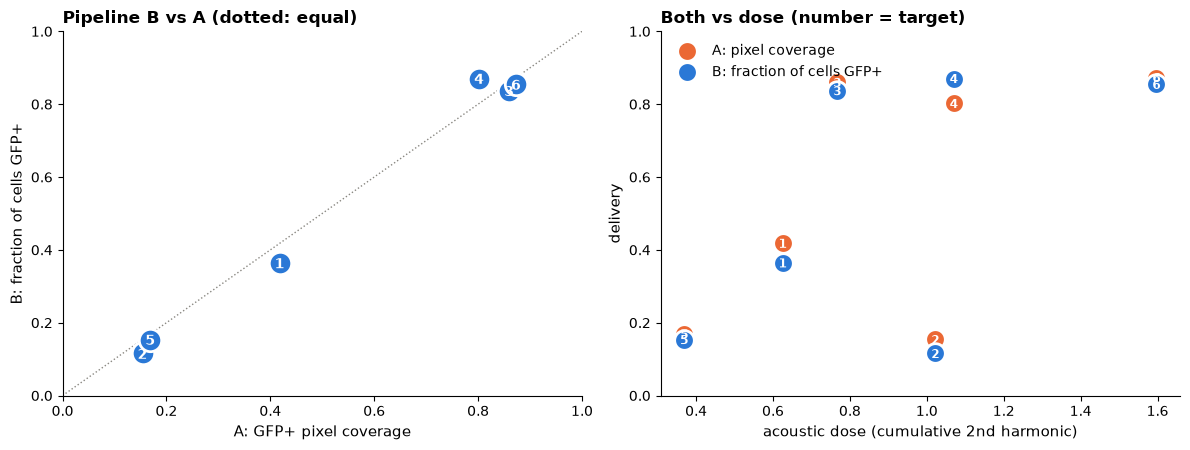

In [3]:
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#898781"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

ax1.plot([0, 1], [0, 1], color=MUTED, linestyle=":", linewidth=1)
ax1.scatter(table["A: pixel coverage"], table["B: fraction cells GFP+"], s=260, color=BLUE,
            edgecolors="white", linewidths=2, zorder=3)
for t, r in table.iterrows():
    ax1.annotate(str(t), (r["A: pixel coverage"], r["B: fraction cells GFP+"]), ha="center",
                 va="center_baseline", color="white", weight="bold", zorder=4)
ax1.set(xlim=(0, 1), ylim=(0, 1))
ax1.set_xlabel("A: GFP+ pixel coverage", fontsize=11)
ax1.set_ylabel("B: fraction of cells GFP+", fontsize=11)
ax1.set_title("Pipeline B vs A (dotted: equal)", loc="left", fontsize=12, weight="bold")

for col, colour, name in (("A: pixel coverage", ORANGE, "A: pixel coverage"),
                          ("B: fraction cells GFP+", BLUE, "B: fraction of cells GFP+")):
    ax2.scatter(table.dose, table[col], s=200, color=colour, edgecolors="white", linewidths=2,
                zorder=3, label=name)
    for t, r in table.iterrows():
        ax2.annotate(str(t), (r.dose, r[col]), ha="center", va="center_baseline", color="white",
                     weight="bold", fontsize=8.5, zorder=4)
ax2.set_ylim(0, 1)
ax2.set_xlabel("acoustic dose (cumulative 2nd harmonic)", fontsize=11)
ax2.set_ylabel("delivery", fontsize=11)
ax2.set_title("Both vs dose (number = target)", loc="left", fontsize=12, weight="bold")
ax2.legend(frameon=False, loc="upper left")
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [4]:
# napari: four layers -- NeuN, GFP stain, GFP+ cells, GFP- cells -- plus the ROI circles.
# Zoomed out you see the whole section (4x overview); zoom into a target and the layers switch
# to full resolution (the six ROI crops, assembled on demand). Front up, notch left.
import dask.array as da

ds4 = cells.ds4_path(MOUSE, SECTION)
sec = histology.load_section(ds4)
ds4_um = sec.pixel_um
full_um = ds4_um / cells.DS4
shape = (sec.shape[0] * cells.DS4, sec.shape[1] * cells.DS4)   # full-resolution canvas
shapes, _ = cells.section_rois(MOUSE, SECTION)

# Load each ROI crop and split its cells into GFP+ / GFP- (cell ids made unique per section).
pieces = {"neun": [], "gfp": [], "pos": [], "neg": []}
offset = 0
for t, roi in sorted(shapes.items()):
    x, y, _, _ = cells.box(roi, full_um)
    crop = tifffile.TiffFile(work / f"{SECTION}_T{t}.ome.tif").series[0].levels[0].asarray()
    labels = tifffile.imread(work / f"{SECTION}_T{t}_labels.tif").astype(np.uint32)
    c = per_cell[per_cell.target == t]
    ids = labels + np.where(labels > 0, offset, 0)
    pos_ids = c.label[c.gfp_positive].to_numpy() + offset
    neg_ids = c.label[~c.gfp_positive].to_numpy() + offset
    pieces["neun"].append((y, x, crop[cells.NEUN]))
    pieces["gfp"].append((y, x, crop[cells.GFP]))
    pieces["pos"].append((y, x, np.where(np.isin(ids, pos_ids), ids, 0)))
    pieces["neg"].append((y, x, np.where(np.isin(ids, neg_ids), ids, 0)))
    offset += int(labels.max())


def mosaic(parts, dtype, chunk=2048):
    """Lazy full-resolution canvas with each (row, col, array) pasted in; zeros elsewhere."""
    def fill(block, block_info=None):
        (r0, r1), (c0, c1) = block_info[None]["array-location"]
        out = np.zeros((r1 - r0, c1 - c0), dtype)
        for y, x, a in parts:
            rr0, rr1 = max(r0, y), min(r1, y + a.shape[0])
            cc0, cc1 = max(c0, x), min(c1, x + a.shape[1])
            if rr0 < rr1 and cc0 < cc1:
                out[rr0 - r0:rr1 - r0, cc0 - c0:cc1 - c0] = a[rr0 - y:rr1 - y, cc0 - x:cc1 - x]
        return out
    return da.zeros(shape, dtype=dtype, chunks=chunk).map_blocks(fill, dtype=dtype)


def image_levels(name, channel):
    """Full-resolution crops at level 0; the whole-section overview below that."""
    overview = sec.channels[channel]
    return [mosaic(pieces[name], overview.dtype), overview, overview[::4, ::4]]


def label_levels(name):
    full = mosaic(pieces[name], np.uint32)
    return [full, full[::cells.DS4, ::cells.DS4], full[::4 * cells.DS4, ::4 * cells.DS4]]


bg = B.background.iloc[0]
place = dict(scale=(full_um, full_um), units="um")
viewer = napari.Viewer(title=f"Pipeline B — Mouse {MOUSE} {SECTION}")
viewer.add_image(image_levels("neun", "CY5"), multiscale=True, name="NeuN (CY5)", colormap="gray",
                 opacity=0.4, blending="additive",
                 contrast_limits=tuple(np.percentile(sec.channels["CY5"][::4, ::4], [1, 99.8])), **place)
viewer.add_image(image_levels("gfp", "TRITC"), multiscale=True, name="GFP stain (TRITC)",
                 colormap="green", blending="additive", contrast_limits=(0.5 * bg, 25 * bg), **place)
for name, key, colour in ((f"GFP+ cells ({int(per_cell.gfp_positive.sum()):,})", "pos", "yellow"),
                          (f"GFP- cells ({int((~per_cell.gfp_positive).sum()):,})", "neg", "magenta")):
    layer = viewer.add_labels(label_levels(key), multiscale=True, name=name, **place)
    layer.colormap = DirectLabelColormap(color_dict={None: colour, 0: "transparent"})
    layer.contour = 2
viewer.add_shapes([roi.corners() for _, roi in sorted(shapes.items())], shape_type="ellipse",
                  name="ROIs", edge_color="white", face_color="transparent", edge_width=6,
                  scale=(ds4_um, ds4_um), units="um")

# Straighten (front up, notch left) in µm, applied after each layer's own scale.
a = orientation.read_sheet()[(MOUSE, SECTION)]
affine = orientation.canonical_affine(a, scale=1 / ds4_um)
if affine is not None:
    for layer in viewer.layers:
        layer.affine = affine
viewer.canvas.overlays.scale_bar.visible = True
viewer.reset_view()

Five layers: **NeuN**, **GFP stain**, **GFP+ cells** (yellow outlines), **GFP− cells** (magenta) and the **ROIs**. Zoomed out, the stains show the whole section at overview resolution; zoom into a target and they switch to full resolution. Yellow outlines should sit on GFP-filled cells and magenta ones should be dim. Cells outside an ROI circle are segmented but not drawn or counted.

When this looks right: `.venv/bin/python -m fus.cells --mouse 2 --all` (and `--mouse 1`) runs pipeline B on every clicked section, writing `results/histology/cells/mouseNN_cell_rois.csv`. Crops are deleted after measuring unless you add `--keep-crops`.